<a href="https://colab.research.google.com/github/johanmorpar/Data_Analyst_Proyects/blob/main/Lappiz_Data_Mining_con_Sismos_(USGS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🦖Data Mining con API - Sismos (USGS)**

##### **¿Qué es un API?**

Un **API (Application Programming Interface)** permite que diferentes aplicaciones se comuniquen entre sí.

En Ciencia de Datos los APIs son fundamentales porque:
- Permiten acceso automatizado a información
- Devuelven datos en formato JSON
- Son ampliamente utilizados en servicios web

> API → JSON → Exploración → DataFrame  → Transformacion y limpieza → Calculos y Estadistica → Visualizacion.

### **1 - Conectarnos al API**

----


> Endpoint:
> https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson

In [9]:
import requests #petición HTTP para descargar los datos

In [10]:
# CARGA DE DATOS DESDE WEB
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson'
print("Conectando y descargando datos desde el servidor gubernamental...")

response = requests.get(url)
response.raise_for_status()
print(f"  Estado HTTP: {response.status_code} (OK)")


Conectando y descargando datos desde el servidor gubernamental...
  Estado HTTP: 200 (OK)


In [11]:
data = response.json()

### **2 - Explorando (EDA) la estructura del JSON**

---

Antes de convertir un archivo JSON complejo o anidado en una tabla de Pandas, es fundamental inspeccionar sus llaves principales, tipos de datos y niveles de anidación para mapear correctamente las variables.

In [12]:
# Ver las llaves principales del diccionario original
llaves_principales = list(data.keys())
print("1. Llaves principales encontradas en la raíz del JSON:")
print(llaves_principales)

1. Llaves principales encontradas en la raíz del JSON:
['type', 'metadata', 'features', 'bbox']


In [13]:
# Validar el contenido de la sección 'metadata'
print("2. Resumen de Metadatos del Dataset:")
for llave, valor in data['metadata'].items():
    print(f"   - {llave}: {valor}")

2. Resumen de Metadatos del Dataset:
   - generated: 1784923544000
   - url: https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson
   - title: USGS All Earthquakes, Past Month
   - status: 200
   - api: 2.7.0
   - count: 10561


In [14]:
# Tomamos el primer registro como muestra
muestra_registro = data['features'][0]

print("3. Diagnóstico de la estructura de un registro individual:")
print(f"Tipo de objeto: {type(muestra_registro)}")
print(f"Llaves internas del registro: {list(muestra_registro.keys())}")
print(f"Tipo de estructura en 'properties': {type(muestra_registro['properties'])}")

3. Diagnóstico de la estructura de un registro individual:
Tipo de objeto: <class 'dict'>
Llaves internas del registro: ['type', 'properties', 'geometry', 'id']
Tipo de estructura en 'properties': <class 'dict'>


cada registro de un sismo tiene su propia estructura interna (id, type, properties, geometry) toda la información analítica está compactada dentro de la variable properties.

In [15]:
# Extraemos las llaves internas de 'properties'
lista_propiedades = list(muestra_registro['properties'].keys())

print("=" * 50)
print(f" LISTA DE PROPIEDADES DISPONIBLES ({len(lista_propiedades)} en total):")
print("=" * 50)

for i, propiedad in enumerate(lista_propiedades, start=1):
    print(f"{i}. {propiedad}")

 LISTA DE PROPIEDADES DISPONIBLES (26 en total):
1. mag
2. place
3. time
4. updated
5. tz
6. url
7. detail
8. felt
9. cdi
10. mmi
11. alert
12. status
13. tsunami
14. sig
15. net
16. code
17. ids
18. sources
19. types
20. nst
21. dmin
22. rms
23. gap
24. magType
25. type
26. title


📋 Glosario de Variables dentro de properties:

**mag** (Magnitud): Es el tamaño o energía liberada por el sismo. Es una variable numérica continua fundamental para filtrar terremotos por su nivel de peligro (por ejemplo, mayores a 5.0).

**place** (Lugar): Una descripción de texto de la ubicación geográfica aproximada del sismo (por ejemplo, "25km SV of Trinidad, Colorado"). Ideal para análisis de texto y agrupación por regiones.

**time** (Tiempo): La fecha y hora exacta en la que ocurrió el sismo. Viene expresada en milisegundos en formato Epoch/Unix, por lo que requiere ser convertida con Pandas a formato fecha legible (datetime).

**updated** (Actualizado): La marca de tiempo de la última vez que se modificó o recalculó el registro de ese sismo en los sistemas de la USGS.

**tz** (Zona Horaria): El desfase de tiempo (offset) en minutos respecto al huso horario UTC del epicentro del sismo (campo que suele estar en desuso o nulo en eventos globales recientes).

**url** (Enlace): Una dirección web directa a la página oficial de la USGS que contiene el reporte técnico e interactivo detallado de ese sismo en particular.

**detail** (Detalle): La URL de la sub-API específica que contiene el JSON con la telemetría extendida de ese único evento (geometría, estaciones que lo reportaron, etc.).

**felt** (Sentido): El número total de reportes públicos recibidos a través del sistema "¿Sintió un terremoto?" de la USGS. Es excelente para medir el impacto social de un sismo.

**cdi** (Intensidad Comunitaria): La intensidad máxima reportada por la comunidad en la escala de Mercalli Modificada. Es una escala subjetiva basada en la percepción humana y daños visuales.

**mmi** (Intensidad Instrumental): La intensidad máxima estimada mediante sensores e instrumentos técnicos automáticos en el epicentro.

**alert** (Alerta): Una bandera de código de color basada en el sistema PAGER (Verde, Amarillo, Naranja, Rojo) que estima el nivel de fatalidades y daños económicos potenciales de inmediato.

**status** (Estado): Indica si el sismo fue revisado por un sismólogo humano (reviewed) o si el registro fue procesado únicamente de manera automática por el sistema (automatic).

**tsunami** (Tsunami): Una variable binaria (0 o 1). Indica con un 1 si el sismo generó de manera interna una alerta o evaluación de riesgo de tsunami en zonas costeras.

**sig** (Significancia): Un número calculado por la USGS (de 0 a 1000) que determina qué tan importante o "noticioso" fue el evento, combinando magnitud, reportes de impacto (felt) y alertas de tsunami.

**net** (Red): El identificador de la red sismológica que recolectó originalmente los datos y reportó el evento a la base de datos central de la USGS (por ejemplo, us, nc, ci).

**code** (Código): El identificador único asignado por la red sismológica de origen para ese sismo específico.

**ids** (Identificadores): Una cadena de texto que agrupa todos los códigos con los que diferentes redes mundiales asociaron a este mismo evento (útil para evitar duplicados si cruzas bases de datos).

**sources** (Fuentes): Una lista de todas las redes o instituciones científicas que aportaron datos para calcular la localización y magnitud finales del sismo.

**types** (Tipos de datos): Una lista de los tipos de productos de datos disponibles para este evento (como mapas de intensidad, archivos de falla, telemetría de ondas, etc.).

**nst** (Número de Estaciones): La cantidad total de estaciones sismológicas que se utilizaron para determinar de manera precisa la localización del sismo.

**dmin** (Distancia Mínima): La distancia horizontal desde el epicentro hasta la estación sismológica más cercana (expresada en grados dipolares). A menor distancia, mayor precisión en la profundidad.

**rms** (Error RMS): El error cuadrático medio del tiempo de viaje de las ondas sísmicas (en segundos). Mide la calidad del ajuste matemático de la localización del sismo (valores cercanos a cero son ideales).

**gap** (Brecha Azimutal): El espacio angular más grande sin cobertura de estaciones alrededor del epicentro (en grados). Si el gap es menor a 180°, la localización del sismo suele ser muy confiable.

**magType** (Tipo de Magnitud): El método o escala científica utilizada para calcular la magnitud del sismo (por ejemplo, mw para Magnitud de Momento, o mb para Ondas de Cuerpo).

**type** (Tipo de Evento): Clasifica la naturaleza del movimiento telúrico. Aunque la mayoría son earthquake (terremotos), también registra actividades como quarry blast (explosiones de canteras), ice quake (sismos de hielo) o explosion.

In [16]:
# Tomamos las propiedades del primer sismo
propiedades_muestra = data['features'][0]['properties']

print("=" * 70)
print(" EJEMPLO DE VALORES REALES EN LA PRIMERA FILA:")
print("=" * 70)

# Imprimimos la llave y su valor real
for llave, valor in propiedades_muestra.items():
    print(f"-> {llave.ljust(12)} : {valor}")

 EJEMPLO DE VALORES REALES EN LA PRIMERA FILA:
-> mag          : 0.83
-> place        : 7 km WNW of Cobb, CA
-> time         : 1784923439080
-> updated      : 1784923533928
-> tz           : None
-> url          : https://earthquake.usgs.gov/earthquakes/eventpage/nc75405167
-> detail       : https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/nc75405167.geojson
-> felt         : None
-> cdi          : None
-> mmi          : None
-> alert        : None
-> status       : automatic
-> tsunami      : 0
-> sig          : 11
-> net          : nc
-> code         : 75405167
-> ids          : ,nc75405167,
-> sources      : ,nc,
-> types        : ,nearby-cities,origin,phase-data,
-> nst          : 9
-> dmin         : 0.005965
-> rms          : 0.02
-> gap          : 72
-> magType      : md
-> type         : earthquake
-> title        : M 0.8 - 7 km WNW of Cobb, CA


In [ ]:
response.json()

### **3 - Estructurando la información del dataframe**

---

In [17]:
import pandas as pd #crear y manipular el DataFrame

**3.1 Primero elegimos un solo sismo (por ejemplo, el primer registro) y extraemos sus variables principales desde la llave 'properties'.**





In [18]:
# 1. Tomamos el primer registro de la lista de sismos como muestra
sismo_muestra = data['features'][0]['properties']

# 2. Extraemos las variables individuales que queramos analizar
place = sismo_muestra['place']
mag = sismo_muestra['mag']
type_event = sismo_muestra['type']
tsunami = sismo_muestra['tsunami']

# 3. Empaquetamos las variables en un diccionario de listas
sismo_dict = {
    'place': [place],
    'mag': [mag],
    'type': [type_event],
    'tsunami': [tsunami]
}

# 4. Creamos el DataFrame
df_muestra = pd.DataFrame(sismo_dict)
df_muestra

,place,mag,type,tsunami
0,"7 km WNW of Cobb, CA",0.83,earthquake,0


**3.2 crear el DataFrame con los +10,000 registros completos**

In [20]:
# Convierte toda la lista de miles de terremotos en una tabla completa
lista_propiedades = [sismo['properties'] for sismo in data['features']]

# DataFrame con todos los registros y todas las columnas
df_sismos = pd.DataFrame(lista_propiedades)

# Muestra de las columnas principales
df_sismos[['place', 'mag', 'type', 'tsunami']].head(5)

,place,mag,type,tsunami
0,"7 km WNW of Cobb, CA",0.83,earthquake,0
1,"24 km SSW of Hawthorne, Nevada",1.75,earthquake,0
2,"4 km SSW of Pāhala, Hawaii",1.77,earthquake,0
3,"4 km SE of The Geysers, CA",1.14,earthquake,0
4,"24 km NE of Arvin, CA",1.20,earthquake,0


In [21]:
df_sismos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mag      10560 non-null  float64
 1   place    10561 non-null  object 
 2   time     10561 non-null  int64  
 3   updated  10561 non-null  int64  
 4   tz       0 non-null      object 
 5   url      10561 non-null  object 
 6   detail   10561 non-null  object 
 7   felt     489 non-null    float64
 8   cdi      489 non-null    float64
 9   mmi      194 non-null    float64
 10  alert    78 non-null     object 
 11  status   10561 non-null  object 
 12  tsunami  10561 non-null  int64  
 13  sig      10561 non-null  int64  
 14  net      10561 non-null  object 
 15  code     10561 non-null  object 
 16  ids      10561 non-null  object 
 17  sources  10561 non-null  object 
 18  types    10561 non-null  object 
 19  nst      10550 non-null  float64
 20  dmin     10543 non-null  float64
 21  rms      105

**3.3 Clasificación de variables cuantitativas y cualitativas**

In [22]:
import numpy as np #Calculos y manejo de valores nulos

In [23]:
#Detectar columnas que contienen listas (cols_lista)
cols_lista = [
    col for col in df_sismos.columns
    if df_sismos[col].apply(lambda x: isinstance(x, list)).any()
]

**cols_lista** = [ ... ]
: Crea una nueva variable llamada cols_lista mediante una comprensión de listas.

**col for col in df_sismos.columns**
: Es un bucle que recorre, una por una, todas las columnas existentes en el DataFrame df_sismos. En cada vuelta, la variable col toma el nombre de una columna (por ejemplo: 'mag', 'place', 'sources', etc.).

**if df_sismos[col].apply(lambda x: isinstance(x, list)).any()**
: Es la condición para incluir la columna en la lista final. Se desglosa así de adentro hacia afuera:

In [24]:
#Filtrar variables cuantitativas (cuantitativas)

cuantitativas = df_sismos.select_dtypes(include=[np.number]).columns.tolist()

**df_sismos.select_dtypes(include=[np.number])**
: Filtra la tabla entera y selecciona únicamente las columnas cuyo tipo de dato sea numérico (tanto enteros int como decimales float).

**.columns**
: Extrae solo los nombres de las columnas resultantes de ese filtro (en lugar de traer todos los datos almacenados en ellas).

**.tolist()**
: Convierte ese objeto de nombres de columnas de Pandas a una lista nativa de Python.

In [25]:
#Filtrar variables cualitativas (cualitativas)
cualitativas = [
    col for col in df_sismos.select_dtypes(include=["object", "bool"]).columns
    if col not in cols_lista
]

**cualitativas = [ ... ]**
: Abre una segunda comprensión de listas para almacenar las columnas categóricas o de texto.

**col for col in df_sismos.select_dtypes(include=["object", "bool"]).columns**
: Busca y recorre únicamente las columnas cuyos tipos de datos sean texto/objetos ("object") o verdaderos/falsos ("bool").

**if col not in cols_lista**
: Es un filtro de exclusión clave: verifica que la columna de texto no haya sido clasificada previamente como una lista en el paso 1. Esto evita que columnas multivaluadas (como sources) se dupliquen por error dentro de las variables cualitativas simples.

In [26]:
#RESULTADOS DE VARIABLES

print(f"\n Variables CUANTITATIVAS (numéricas): {len(cuantitativas)}")
for v in cuantitativas:
    print(f"   • {v:20s} -> {df_sismos[v].dtype}")

print(f"\n Variables CUALITATIVAS (categóricas/texto): {len(cualitativas)}")
for v in cualitativas:
    print(f"   • {v:20s} -> {df_sismos[v].dtype}")

print(f"\n Variables tipo LISTA (multivaluadas): {len(cols_lista)}")
for v in cols_lista:
    print(f"   • {v:20s} -> lista de valores")


 Variables CUANTITATIVAS (numéricas): 12
   • mag                  -> float64
   • time                 -> int64
   • updated              -> int64
   • felt                 -> float64
   • cdi                  -> float64
   • mmi                  -> float64
   • tsunami              -> int64
   • sig                  -> int64
   • nst                  -> float64
   • dmin                 -> float64
   • rms                  -> float64
   • gap                  -> float64

 Variables CUALITATIVAS (categóricas/texto): 14
   • place                -> object
   • tz                   -> object
   • url                  -> object
   • detail               -> object
   • alert                -> object
   • status               -> object
   • net                  -> object
   • code                 -> object
   • ids                  -> object
   • sources              -> object
   • types                -> object
   • magType              -> object
   • type                 -> object
   • 

### **4. Preprocesamiento: Limpieza de datos & Feature Engineering**
----

**4.1 Copia de Respaldo y Selección de Columnas Utiles**

En esta primera etapa creamos una copia del DataFrame original para no perder los datos crudos y eliminamos las columnas que son redundantes o técnicas que no aportan al análisis.

Se seleccionaron 18 columnas estratégicas que responden a las dimensiones de evento (mag, type), espacio (place), tiempo (time) e impacto/calidad (felt, alert, gap). Este filtro elimina variables técnicas y enlaces innecesarios para centrar el análisis en la energía liberada, la ubicación, el riesgo social y la precisión de los datos. Así se optimiza el uso de memoria y se garantiza una base limpia para el Feature Engineering y el cálculo de estadísticas.

In [27]:
# Crear una copia de seguridad para trabajar sobre ella
df_limpio = df_sismos.copy()

# Definir las columnas útiles para nuestro análisis
columnas_interes = [
    'mag', 'place', 'time', 'updated', 'felt', 'cdi', 'mmi',
    'alert', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
    'rms', 'gap', 'magType', 'type'
]

# Filtrar el DataFrame
df_limpio = df_limpio[columnas_interes]

print(f" Copia creada. Dimensiones actuales: {df_limpio.shape[0]} filas y {df_limpio.shape[1]} columnas.")

 Copia creada. Dimensiones actuales: 10561 filas y 18 columnas.


**4.2 Conversión de Fechas (Epoch a Datetime)**

In [28]:
# Convertir de milisegundos a formato Datetime con Pandas
df_limpio['fecha_hora'] = pd.to_datetime(df_limpio['time'], unit='ms')
df_limpio['fecha_actualizacion'] = pd.to_datetime(df_limpio['updated'], unit='ms')

# Eliminar las columnas originales en milisegundos para no duplicar datos
df_limpio.drop(columns=['time', 'updated'], inplace=True)

print(" Fechas convertidas con éxito.")
print(df_limpio[['fecha_hora', 'fecha_actualizacion']].head(5))

 Fechas convertidas con éxito.
               fecha_hora     fecha_actualizacion
0 2026-07-24 20:03:59.080 2026-07-24 20:05:33.928
1 2026-07-24 19:59:21.397 2026-07-24 20:01:41.030
2 2026-07-24 19:57:47.830 2026-07-24 20:01:38.180
3 2026-07-24 19:53:39.100 2026-07-24 19:55:13.232
4 2026-07-24 19:50:19.820 2026-07-24 19:53:48.365


**4.3 Feature Engineering Geográfico (Limpieza de place)**

In [29]:
# Función para extraer la región o país, despues de la coma ','.
def extraer_region(texto):
    if isinstance(texto, str) and ',' in texto:
        return texto.split(',')[-1].strip()
    elif isinstance(texto, str):
        return texto.strip()
    return 'Desconocido'

# Crear la columna de Región / Estado
df_limpio['region'] = df_limpio['place'].apply(extraer_region)

# Estandarizar a mayúsculas para evitar duplicados por formato
df_limpio['region'] = df_limpio['region'].str.title()

print(" Extracción geográfica completada.")
print(df_limpio[['place', 'region']].head(10))

 Extracción geográfica completada.
                                               place     region
0                               7 km WNW of Cobb, CA         Ca
1                     24 km SSW of Hawthorne, Nevada     Nevada
2                         4 km SSW of Pāhala, Hawaii     Hawaii
3                         4 km SE of The Geysers, CA         Ca
4                              24 km NE of Arvin, CA         Ca
5                    86 km SSE of Sand Point, Alaska     Alaska
6                               7 km WNW of Cobb, CA         Ca
7                     24 km SSW of Hawthorne, Nevada     Nevada
8  47 km WNW of San Antonio de los Cobres, Argentina  Argentina
9                          13 km SE of Tehachapi, CA         Ca


**4.4 Tratamiento Estratégico de Valores Nulos (NaN)**

In [30]:
# Variable'felt' (reportes de personas): Si es NaN, significa que 0 personas lo reportaron
df_limpio['felt'] = df_limpio['felt'].fillna(0).astype(int)

# Variable 'tsunami': Si es NaN, asumimos que no hubo alerta (0)
df_limpio['tsunami'] = df_limpio['tsunami'].fillna(0).astype(int)

# Variable 'alert': Si es NaN, asignamos la categoría 'sin_alerta'
df_limpio['alert'] = df_limpio['alert'].fillna('sin_alerta')

# Variable 'mag' (magnitud): Si hay registros sin magnitud, los eliminamos (no sirven para el análisis)
df_limpio.dropna(subset=['mag'], inplace=True)

print(" Valores nulos tratados correctamente.")


 Valores nulos tratados correctamente.


In [31]:
#Comprobar que ya NO hay valores nulos
print("--- Cantidad de valores nulos restantes por columna ---")
print(df_limpio.isnull().sum())

--- Cantidad de valores nulos restantes por columna ---
mag                        0
place                      0
felt                       0
cdi                    10071
mmi                    10366
alert                      0
status                     0
tsunami                    0
sig                        0
net                        0
nst                       11
dmin                      18
rms                       12
gap                       12
magType                    0
type                       0
fecha_hora                 0
fecha_actualizacion        0
region                     0
dtype: int64


In [32]:
#Diagnóstico de los datos nulos restantes: cdi y mmi (~10,000 nulos) y tambien: nst, dmin, rms, gap (entre 11 y 17 nulos)

# 1. Imputar intensidades (cdi y mmi) con 0
df_limpio['cdi'] = df_limpio['cdi'].fillna(0)
df_limpio['mmi'] = df_limpio['mmi'].fillna(0)

# 2. Imputar nst (número de estaciones) con 0 y convertir a entero
df_limpio['nst'] = df_limpio['nst'].fillna(0).astype(int)

# 3. Imputar dmin, rms y gap con la mediana de cada columna
for col in ['dmin', 'rms', 'gap']:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)



In [33]:
# Verificar nuevamente los nulos
print("--- Confirmación final de nulos ---")
print(df_limpio.isnull().sum(), "nulos totales en la tabla.")

--- Confirmación final de nulos ---
mag                    0
place                  0
felt                   0
cdi                    0
mmi                    0
alert                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                    0
dmin                   0
rms                    0
gap                    0
magType                0
type                   0
fecha_hora             0
fecha_actualizacion    0
region                 0
dtype: int64 nulos totales en la tabla.


**4.5 Creación de Variables Categóricas Útiles**

Agrupamos las magnitudes continuas en rangos discretos según la escala sismológica para facilitar la generación de informes y gráficos.

In [34]:
# Definir límites y etiquetas para la escala de magnitudes
limites_mag = [-np.inf, 2.5, 4.5, 6.0, 7.0, np.inf] # En NumPy: límite inferior (-np.inf) y limite superior (np.inf)
etiquetas_mag = ['Micro (<2.5)', 'Menor (2.5-4.4)', 'Moderado (4.5-5.9)', 'Fuerte (6.0-6.9)', 'Mayor (>=7.0)']

# Crear la nueva variable categorizada
df_limpio['categoria_magnitud'] = pd.cut( #pd.cut(...) función para segmentar y clasificar valores numéricos en intervalos discretos
    df_limpio['mag'],
    bins=limites_mag, #bins: define las fronteras de los intervalos
    labels=etiquetas_mag #etiquetas: nombres que recibirá cada intervalo
)

# Extraer hora y día de la semana para análisis temporal
df_limpio['hora_dia'] = df_limpio['fecha_hora'].dt.hour
df_limpio['dia_semana'] = df_limpio['fecha_hora'].dt.day_name()

print(" Variables de Feature Engineering agregadas.")

 Variables de Feature Engineering agregadas.


**4.6 Verificación Final del Dataset Limpio**

In [35]:
print("=" * 80)
print(" RESUMEN DEL DATAFRAME PROCESADO Y LIMPIO")
print("=" * 80)
print(f"• Registros totales: {len(df_limpio):,}")
print(f"• Total de columnas: {df_limpio.shape[1]}")
print(f"• Valores nulos restantes en 'mag': {df_limpio['mag'].isnull().sum()}")
print("\n--- Vista previa de las columnas clave ---")
print(df_limpio[['fecha_hora', 'region', 'mag', 'categoria_magnitud', 'felt', 'alert']].head(5))

 RESUMEN DEL DATAFRAME PROCESADO Y LIMPIO
• Registros totales: 10,560
• Total de columnas: 22
• Valores nulos restantes en 'mag': 0

--- Vista previa de las columnas clave ---
               fecha_hora  region   mag categoria_magnitud  felt       alert
0 2026-07-24 20:03:59.080      Ca  0.83       Micro (<2.5)     0  sin_alerta
1 2026-07-24 19:59:21.397  Nevada  1.75       Micro (<2.5)     0  sin_alerta
2 2026-07-24 19:57:47.830  Hawaii  1.77       Micro (<2.5)     0  sin_alerta
3 2026-07-24 19:53:39.100      Ca  1.14       Micro (<2.5)     0  sin_alerta
4 2026-07-24 19:50:19.820      Ca  1.20       Micro (<2.5)     0  sin_alerta


### **5. Procesamiento: Estadisticas y Calculos**

---

**5.1 Resumen Estadístico Global** (Variables Continuas: mag, felt, cdi, mmi, nst, dmin, rms, gap)

Calculamos la media, mediana, desviación estándar, IQR, mínimos y máximos de las variables numéricas clave:

In [36]:
# Columnas numéricas continuas principales
cols_continuas = ['mag', 'felt', 'cdi', 'mmi', 'nst', 'dmin', 'rms', 'gap']

# Construir tabla de estadísticas descriptivas completas
resumen_continuas = pd.DataFrame({
    'Media': df_limpio[cols_continuas].mean(),
    'Mediana (Q2)': df_limpio[cols_continuas].median(),
    'Desv. Estándar': df_limpio[cols_continuas].std(),
    'Q1 (25%)': df_limpio[cols_continuas].quantile(0.25),
    'Q3 (75%)': df_limpio[cols_continuas].quantile(0.75),
    'IQR': df_limpio[cols_continuas].quantile(0.75) - df_limpio[cols_continuas].quantile(0.25),
    'Mínimo': df_limpio[cols_continuas].min(),
    'Máximo': df_limpio[cols_continuas].max(),
    'Asimetría (Skew)': df_limpio[cols_continuas].skew()
})

print("="*80)
print(" RESUMEN NUMÉRICO GLOBAL (VARIABLES CONTINUAS)")
print("="*80)
display(resumen_continuas.round(2))

 RESUMEN NUMÉRICO GLOBAL (VARIABLES CONTINUAS)


,Media,Mediana (Q2),Desv. Estándar,Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,Asimetría (Skew)
mag,1.68,1.50,1.24,0.85,2.10,1.25,-1.31,7.50,1.07
felt,1.26,0.00,29.96,0.00,0.00,0.00,0.00,2028.00,43.73
cdi,0.10,0.00,0.56,0.00,0.00,0.00,0.00,8.90,6.37
mmi,0.06,0.00,0.47,0.00,0.00,0.00,0.00,8.69,9.55
nst,25.66,19.00,22.66,11.00,33.00,22.00,0.00,299.00,3.21
dmin,0.56,0.08,1.93,0.03,0.30,0.27,0.00,42.24,9.63
rms,0.30,0.20,0.29,0.10,0.49,0.39,0.00,2.60,1.34
gap,115.83,91.00,70.27,64.00,154.00,90.00,12.00,352.00,1.05


 **Medidas de Tendencia Central y Posición**

 **Mediana (Q2 / 50%)**: Es el valor que está justo en el centro del dataset. Representa al sismo "típico" y es la medida más confiable porque no se deja alterar por valores extremos.

 **Media (Promedio)**: La suma de todos los valores dividida entre el total. Si difiere mucho de la mediana, indica la presencia de datos muy altos o muy bajos.

 **Q1 (25%) y Q3 (75%)**: El Q1 indica que el 25% de los sismos tienen un valor igual o menor a este límite. El Q3 marca el punto donde el 75% de los datos queda por debajo.

 **IQR (Rango Intercuartílico)**: Es la diferencia entre Q3 y Q1 ($IQR = Q3 - Q1$). Mide la dispersión del 50% central de tus datos; mientras más pequeño, más concentrados están los datos.

**Medidas de Dispersión y Forma**

**Mínimo y Máximo**: Determinan los valores extremos (el sismo de menor y mayor magnitud/impacto registrado).

**Desviación Estándar**: Mide qué tanto se alejan los datos en promedio respecto a la media. Una desviación baja indica datos muy agrupados.

**Asimetría (Skewness)**: Indica hacia dónde se inclinan los datos. Un valor positivo alto significa que la gran mayoría de los eventos son pequeños y solo unos pocos son muy grandes (cola a la derecha).

**Frecuencias y Métricas Categóricas**

**Moda**: El valor o categoría que se repite con mayor frecuencia en la columna (ej. la alerta más común o el tipo de evento predominante).

#### **5.2 Resumen Categórico y Frecuencias (Variables Discretas: 'type', 'categoria_magnitud', 'alert', 'tsunami', 'net')**

Analizamos las frecuencias absolutas, relativas (%) y modas de las variables categóricas:

In [37]:
cols_categoricas = ['type', 'categoria_magnitud', 'alert', 'tsunami', 'net']

print("="*80)
print("RESUMEN CATEGÓRICO Y FRECUENCIAS")
print("="*80)

for col in cols_categoricas: #(ciclo) que va a recorrer, una por una, las variables definidas en la lista cols_categoricas
    print(f"\n--- Variable: '{col}' ---") #Imprime un subtítulo que indica qué variable se está analizando en ese momento
    df_freq = pd.DataFrame({ #DataFrame "df_freq" para almacenar y estructurar la tabla de frecuencias de la variable actual.
        'Conteo Absoluto': df_limpio[col].value_counts(), #Cuenta las veces de la categoría en la columna col mediante .value_counts() y asigna esos valores a la columna 'Conteo Absoluto'.
        'Porcentaje (%)': (df_limpio[col].value_counts(normalize=True) * 100).round(2) #value_counts(normalize=True) calcula la frecuencia relativa de cada categoría (valores decimales entre 0 y 1) y redondea.
    })
    display(df_freq)
    print(f"Moda de '{col}': {df_limpio[col].mode()[0]}") #obtiene la moda (el valor o categoría más frecuente de esa columna) y [0] muestra el primer valor.

RESUMEN CATEGÓRICO Y FRECUENCIAS

--- Variable: 'type' ---


,Conteo Absoluto,Porcentaje (%)
type,,
earthquake,10349,98.00
quarry blast,118,1.12
explosion,85,0.80
ice quake,7,0.07
experimental explosion,1,0.01


Moda de 'type': earthquake

--- Variable: 'categoria_magnitud' ---


,Conteo Absoluto,Porcentaje (%)
categoria_magnitud,,
Micro (<2.5),8755,82.91
Menor (2.5-4.4),1354,12.82
Moderado (4.5-5.9),438,4.15
Fuerte (6.0-6.9),10,0.09
Mayor (>=7.0),3,0.03


Moda de 'categoria_magnitud': Micro (<2.5)

--- Variable: 'alert' ---


...

Moda de 'alert': sin_alerta

--- Variable: 'tsunami' ---


,Conteo Absoluto,Porcentaje (%)
tsunami,,
0,10560,100.0


Moda de 'tsunami': 0

--- Variable: 'net' ---


,Conteo Absoluto,Porcentaje (%)
net,,
ak,2087,19.76
nc,1803,17.07
ci,1637,15.50
us,1221,11.56
tx,996,9.43
av,903,8.55
hv,429,4.06
uu,365,3.46
uw,359,3.40


Moda de 'net': ak


####**5.3 Agregaciones por Regionalización (Top 10 Regiones)**

Agrupamos por region para identificar las zonas con mayor actividad y su nivel de severidad:

In [38]:
# Filtrar top 10 regiones con mayor volumen
top_10_regiones = df_limpio['region'].value_counts().head(10).index

geo_stats = df_limpio[df_limpio['region'].isin(top_10_regiones)].groupby('region').agg(
    Total_Sismos=('mag', 'count'),
    Mag_Mediana=('mag', 'median'),
    Mag_Maxima=('mag', 'max'),
    Promedio_Reportes_Felt=('felt', 'mean'),
    Alertas_Tsunami=('tsunami', 'sum')
).sort_values(by='Total_Sismos', ascending=False)

print("="*80)
print("ESTADÍSTICAS AGREGADAS POR TOP 10 REGIONES")
print("="*80)
display(geo_stats.round(2))

ESTADÍSTICAS AGREGADAS POR TOP 10 REGIONES


,Total_Sismos,Mag_Mediana,Mag_Maxima,Promedio_Reportes_Felt,Alertas_Tsunami
region,,,,,
Ca,3406,1.02,4.42,1.02,0
Alaska,3221,1.80,5.40,0.80,0
Texas,779,1.40,5.00,0.64,0
Hawaii,430,1.81,4.53,1.18,0
Washington,293,0.95,3.80,7.38,0
Utah,268,1.11,2.62,0.07,0
Puerto Rico,226,2.33,4.80,1.11,0
New Mexico,219,1.60,3.50,0.01,0
Oklahoma,182,1.21,2.47,0.06,0


**df_limpio['region'].isin(top_10_regiones)**: Crea un filtro booleano para evaluar qué filas pertenecen a las 10 regiones con más actividad.

**.groupby('region')**: Agrupa los datos filtrados tomando como clave el nombre de cada región.

**.agg(...)**: Inicia la aplicación de múltiples funciones de agregación personalizadas para cada grupo.

**).sort_values(by='Total_Sismos', ascending=False)**
: Cierra la función de agregación ".agg()." y
".sort_values(by='Total_Sismos', ascending=False)": Ordena la tabla resultante de forma descendente (ascending=False) tomando como base el volumen de sismos, de modo que la región con más eventos quede en el primer renglón.

#### **5.4 Agregaciones Temporales (Día de la Semana y Hora)**

Analizamos el ritmo de ocurrencia según el día y la hora:

In [39]:
temporal_stats = df_limpio.groupby('dia_semana').agg(
    Total_Sismos=('mag', 'count'),
    Mag_Mediana=('mag', 'median'),
    Mag_Maxima=('mag', 'max')
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']) #Al aplicar .reindex(...), le obligas a presentar los días en su orden natural de la semana, de lunes a domingo.

print("="*80)
print(" DISTRIBUCIÓN SÍSMICA POR DÍA DE LA SEMANA")
print("="*80)
display(temporal_stats)

 DISTRIBUCIÓN SÍSMICA POR DÍA DE LA SEMANA


,Total_Sismos,Mag_Mediana,Mag_Maxima
dia_semana,,,
Monday,1465,1.50,6.4
Tuesday,1380,1.50,6.2
Wednesday,1396,1.50,7.5
Thursday,1821,1.50,5.9
Friday,1582,1.50,7.3
Saturday,1439,1.43,6.4
Sunday,1477,1.47,5.8


#### **5.5 Agregaciones Cruzadas (Interacción de Impacto y Riego)**

Evaluamos la respuesta social y las alertas según la categoría de magnitud:

In [40]:
cruzado_impacto = df_limpio.groupby('categoria_magnitud', observed=False).agg(
    Total_Eventos=('mag', 'count'),
    Mediana_Personas_Sintieron=('felt', 'median'),
    Max_Personas_Sintieron=('felt', 'max'),
    Intensidad_Mediana_CDI=('cdi', 'median'),
    Total_Tsunamis=('tsunami', 'sum')
)
# Agrupa los sismos por su categoría de magnitud (incluyendo todas las categorías definidas aunque no tengan registros,por observed=False) y agrupa múltiples cálculos de impacto mediante .agg().

print("="*80)
print(" 🔗 5. RELACIÓN ENTRE CATEGORÍA DE MAGNITUD E IMPACTO SOCIAL")
print("="*80)
display(cruzado_impacto)

 🔗 5. RELACIÓN ENTRE CATEGORÍA DE MAGNITUD E IMPACTO SOCIAL


,Total_Eventos,Mediana_Personas_Sintieron,Max_Personas_Sintieron,Intensidad_Mediana_CDI,Total_Tsunamis
categoria_magnitud,,,,,
Micro (<2.5),8755,0.0,122,0.00,0
Menor (2.5-4.4),1354,0.0,2028,0.00,0
Moderado (4.5-5.9),438,0.0,484,0.00,0
Fuerte (6.0-6.9),10,4.5,95,3.85,0
Mayor (>=7.0),3,287.0,780,7.40,0


#### **6. Tablas Dinámicas y Pivotaje**

El objetivo de esta fase es cruzar dos o más variables para descubrir patrones ocultos que no se ven a simple vista en los resúmenes de una sola columna.

**6.1  MATRIZ DE RIESGO: Categoria de Magnitud vs. Alertas y Tsunamis**

In [41]:
pivot_alertas = pd.crosstab(
    index=df_limpio['categoria_magnitud'],
    columns=df_limpio['alert'],
    margins=True,            # Agrega los totales por fila y columna
    margins_name='Total'
)

print("="*80)
print(" 🚨 1. MATRIZ DE RIESGO: CATEGORÍA DE MAGNITUD VS. NIVEL DE ALERTA")
print("="*80)
display(pivot_alertas)

 🚨 1. MATRIZ DE RIESGO: CATEGORÍA DE MAGNITUD VS. NIVEL DE ALERTA


alert,green,red,sin_alerta,yellow,Total
categoria_magnitud,,,,,
Micro (<2.5),0,0,8755,0,8755
Menor (2.5-4.4),10,0,1344,0,1354
Moderado (4.5-5.9),53,0,383,2,438
Fuerte (6.0-6.9),9,0,0,1,10
Mayor (>=7.0),0,2,0,1,3
Total,72,2,10482,4,10560


**pd.crosstab(categoria_magnitud, alert)**:
Validar la coherencia de las alertas. Te permite ver exactamente cuántos sismos de cierta magnitud dispararon una alerta verde, amarilla o roja.

**6.2 REGIONALIZACIÓN: Top 10 Regiones vs. Categoria de Magnitud**

In [42]:
top_10 = df_limpio['region'].value_counts().head(10).index
df_top10 = df_limpio[df_limpio['region'].isin(top_10)]

pivot_regiones = pd.crosstab(
    index=df_top10['region'],
    columns=df_top10['categoria_magnitud'],
    normalize='index' # Muestra proporciones (porcentajes) por fila
).round(4) * 100

print("\n"+"="*80)
print("(%) DE CATEGORÍAS DE MAGNITUD EN TOP 10 REGIONES")
print("="*80)
display(pivot_regiones)


(%) DE CATEGORÍAS DE MAGNITUD EN TOP 10 REGIONES


categoria_magnitud,Micro (<2.5),Menor (2.5-4.4),Moderado (4.5-5.9)
region,,,
Alaska,82.96,16.67,0.37
Ca,98.12,1.88,0.00
Hawaii,93.95,5.81,0.23
Montana,98.65,1.35,0.00
New Mexico,98.17,1.83,0.00
Oklahoma,100.00,0.00,0.00
Puerto Rico,63.72,35.84,0.44
Texas,97.82,2.05,0.13
Utah,98.88,1.12,0.00


**pd.crosstab(region, categoria_magnitud, normalize='index'):**

Comparar perfiles de riesgo entre regiones. Al usar normalize='index', conviertes los conteos en porcentajes por fila (100% por región), lo que permite responder: ¿Qué región tiene un mayor porcentaje de sismos "Fuertes"a "Micros"?.

**6.3 Matriz de Calor (Día de la Semana vs. Hora del Día)**

In [43]:
# mostrar la tabla completa
pd.set_option('display.max_columns', None)

# Crear la tabla pivote de frecuencia
pivot_temporal = pd.pivot_table(
    data=df_limpio,
    index='dia_semana',
    columns='hora_dia',
    values='mag',
    aggfunc='count',
    fill_value=0
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print("\n" + "=" * 110)
print(" MAPA DE CALOR: FRECUENCIA DE SISMOS POR DÍA Y HORA DEL DÍA")
print("=" * 110)

#  Aplicar formato visual de mapa de calor
pivot_temporal_styled = pivot_temporal.style.background_gradient(
    cmap='YlOrRd',  # Escala de amarillo (bajo) a rojo (alto)
    axis=None       # Evalúa el máximo y mínimo de toda la matriz a la vez
).format("{:d}")    # Formatea como números enteros sin decimales

# Mostrar la tabla grafica
display(pivot_temporal_styled)


 MAPA DE CALOR: FRECUENCIA DE SISMOS POR DÍA Y HORA DEL DÍA


hora_dia,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
dia_semana,,,,,,,,,,,,,,,,,,,,,,,,
Monday,47,45,69,48,52,65,59,69,70,67,74,76,55,49,51,50,79,73,54,69,63,76,56,49
Tuesday,51,64,38,37,49,67,60,67,54,46,58,77,55,61,58,74,76,45,64,65,57,50,43,64
Wednesday,55,52,48,61,57,45,64,62,61,72,46,70,59,46,52,52,53,53,57,56,69,94,64,48
Thursday,80,75,78,73,77,69,75,114,87,92,65,78,64,59,81,80,82,76,67,84,66,72,61,66
Friday,59,49,57,51,55,67,69,72,73,74,80,60,68,88,65,64,78,75,62,77,58,59,70,52
Saturday,56,60,48,70,83,68,60,63,70,62,58,60,49,54,56,61,53,63,66,66,52,62,44,55
Sunday,57,53,57,59,77,83,50,64,56,55,62,75,47,62,66,65,70,66,58,68,54,55,59,59


**pd.set_option('display.max_columns', None):** Desactiva el límite de columnas visibles para que las 24 horas del día (0 a 23) aparezcan completas en pantalla.

**pd.pivot_table(dia_semana, hora_dia):** Construir la estructura ideal para posteriormente hacer un Mapa de Calor (Heatmap), identificando horas pico de registro sísmico.

**cmap='YlOrRd':** Define la paleta de colores (Yellow-Orange-Red). Las celdas con mayor conteo de sismos se tornarán rojo intenso, haciendo que los patrones temporales resalten al instante.

**axis=None:** Aplica la escala de color comparando todas las celdas del cuadro entre sí, lo que te permite identificar la hora y el día pico global del dataset.

**.format("{:d}"):** Asegura que la tabla muestre enteros limpios (ej. 15 en lugar de 15.0).

## **7.Visualización de Datos (Data Viz).**

In [44]:
import matplotlib.pyplot as plt  # Librería principal para renderizar figuras y gráficos
import seaborn as sns  # Librería para gráficos estadísticos avanzados

**Gráfico 1: Histograma + KDE (Distribución de Magnitudes)**

In [45]:
print(df_limpio.columns.tolist())

['mag', 'place', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type', 'fecha_hora', 'fecha_actualizacion', 'region', 'categoria_magnitud', 'hora_dia', 'dia_semana']


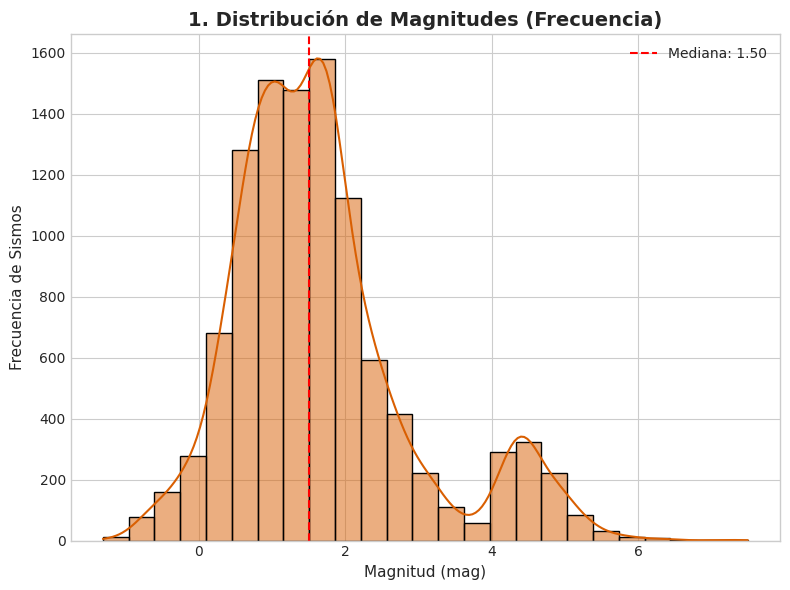

In [46]:
# Define el estilo de fondo con cuadrícula blanca clara
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.rcParams['font.sans-serif'] = (
    'DejaVu Sans'  # Configura la fuente tipográfica a DejaVu Sans
)
plt.rcParams['font.family'] = (
    'sans-serif'  # Establece la familia tipográfica sin serifas
)

# Construcción del Gráfico 1

fig, ax = plt.subplots(
    figsize=(8, 6)
)  # Crea la figura (fig) y su lienzo de ejes de 8x6 pulgadas

# Dibuja el histograma de distribución de magnitudes
sns.histplot(
    data=df_limpio,  # Especifica el DataFrame de origen
    x='mag',  # Asigna la columna 'mag' al eje horizontal X
    kde=True,  # Activa la curva de densidad suavizada (Kernel Density Estimation)
    bins=25,  # Divide el rango numérico en 25 barras de intervalo
    color='#d95f02',  # Aplica color naranja terracota a las barras
    ax=ax,  # Renderiza el gráfico dentro de los ejes 'ax' inicializados
)

# Configuración de textos y etiquetas
ax.set_title(
    '1. Distribución de Magnitudes (Frecuencia)', fontsize=14, fontweight='bold'
)  # Título del gráfico
ax.set_xlabel('Magnitud (mag)', fontsize=11)  # Etiqueta para el eje horizontal X
ax.set_ylabel(
    'Frecuencia de Sismos', fontsize=11
)  # Etiqueta para el eje vertical (Y)

# Marca de tendencia central (Mediana)
mediana_mag = (
    df_limpio['mag'].median()
)  # Calcula el valor de la mediana de magnitudes
ax.axvline(
    mediana_mag, color='red', linestyle='--', label=f'Mediana: {mediana_mag:.2f}'
)  # Traza una línea vertical roja punteada en la mediana
ax.legend()  # Muestra la caja de leyenda con la información de la mediana

plt.tight_layout()  # Ajusta automáticamente los márgenes de la imagen
plt.show()  # Despliega el gráfico terminado en pantalla

**Gráfico 2: Diagrama de Barras Horizontales (Top 10 Regiones)**

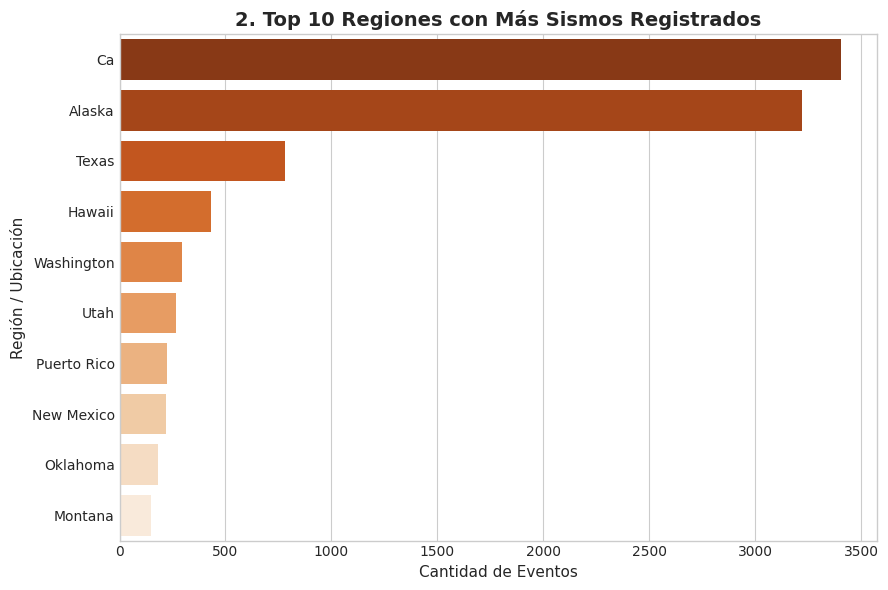

In [47]:
# Define el estilo de fondo con cuadrícula blanca clara
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# Construcción del Gráfico 2

fig, ax = plt.subplots(
    figsize=(9, 6)
)  #figura con dimensiones de 9x6 pulgadas

# Agregación de datos
top_regiones = (
    df_limpio['region'].value_counts().head(10)
)  # Cuenta el total por región y extrae únicamente las 10 más frecuentes

# Dibuja gráfico de barras
sns.barplot(
    x=top_regiones.values,  # Asigna la cantidad numérica de sismos al eje X
    y=top_regiones.index,  # Asigna los nombres de las regiones al eje Y (orientación horizontal)
    palette='Oranges_r',  # Aplica degradado de naranjas (la barra con más sismos será más oscura)
    hue=top_regiones.index,  # Mantiene consistencia de color mapeada por región
    legend=False,  # Oculta la leyenda auxiliar al no ser necesaria
    ax=ax,  # Asigna los ejes de renderizado
)

# Personalización del lienzo
ax.set_title(
    '2. Top 10 Regiones con Más Sismos Registrados',
    fontsize=14,
    fontweight='bold',
)  # Título principal
ax.set_xlabel('Cantidad de Eventos', fontsize=11)  # Etiqueta de frecuencia
ax.set_ylabel('Región / Ubicación', fontsize=11)  # Etiqueta de ubicación

plt.tight_layout()  # Optimiza el espacio de los bordes
plt.show()  # Muestra el gráfico en pantalla

**Gráfico 3: Dispersión (Magnitud vs. Profundidad)**

In [48]:
print(df_limpio.columns.tolist())

['mag', 'place', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type', 'fecha_hora', 'fecha_actualizacion', 'region', 'categoria_magnitud', 'hora_dia', 'dia_semana']


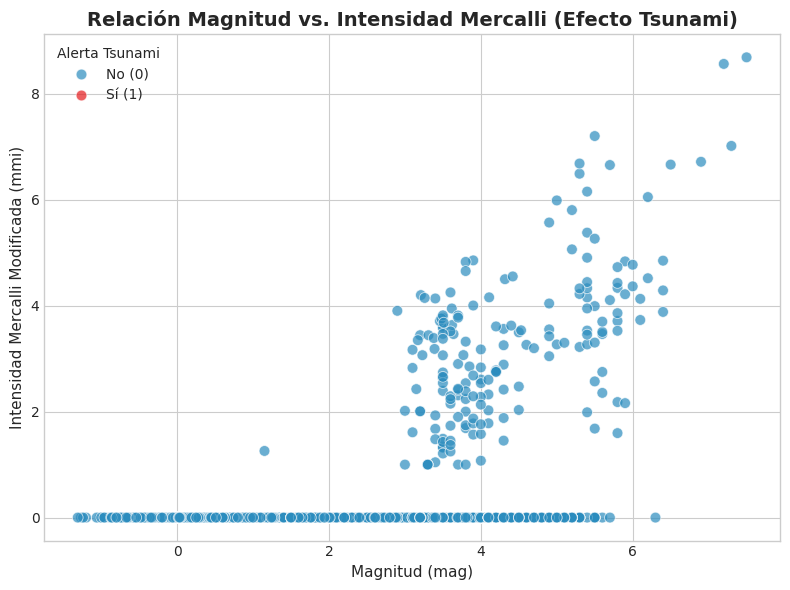

In [49]:
# Define el estilo de fondo con cuadrícula blanca clara

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# Construcción del Gráfico 3: Magnitud vs. Intensidad Mercalli

fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar el gráfico
sns.scatterplot(
    data=df_limpio,
    x='mag',
    y='mmi', # tambien se puede carmbiar a y='mmi' por y='felt' o y='cdi'
    hue='tsunami',
    palette={
        0: '#2b8cbe',
        1: '#e41a1c',
    },  # 0 (No Tsunami) -> Azul | 1 (Sí Tsunami) -> Rojo
    hue_order=[0, 1],  # Garantiza que respete el orden exacto de los valores
    alpha=0.7,
    s=60,
    ax=ax,
)

# Personalización de títulos y etiquetas
ax.set_title(
    'Relación Magnitud vs. Intensidad Mercalli (Efecto Tsunami)',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Magnitud (mag)', fontsize=11)
ax.set_ylabel('Intensidad Mercalli Modificada (mmi)', fontsize=11)

# Configurar leyenda explícita con los colores correctos
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['No (0)', 'Sí (1)'],
    title='Alerta Tsunami',
    loc='upper left',
)

plt.tight_layout()
plt.show()

Si se quiere evaluar los reportes de las personas en lugar de la escala Mercalli, solo se cambia y='mmi' por y='felt' o y='cdi'.

**Gráfico 4: Violín (Distribución de Magnitud por Día de la Semana)**

/tmp/ipykernel_2986/1514389529.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


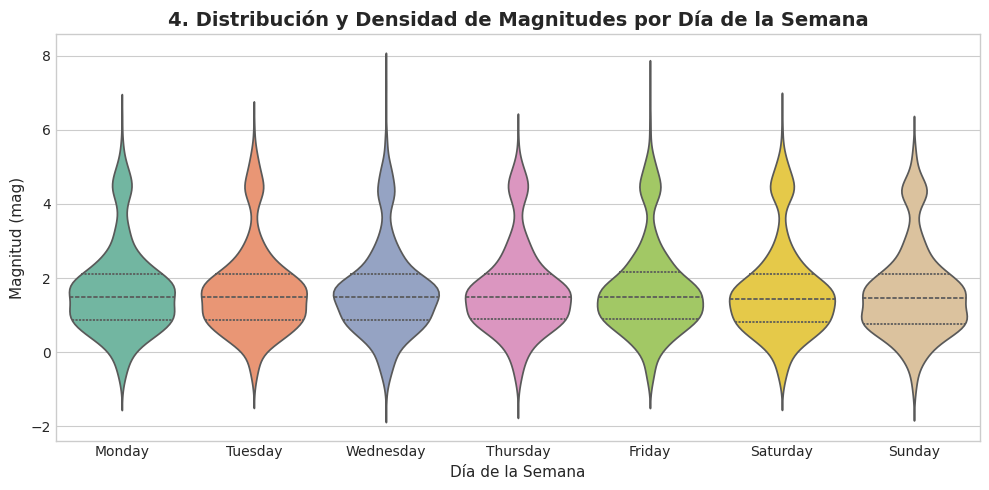

In [50]:
# Define el estilo de fondo con cuadrícula blanca clara
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# Construcción del Gráfico 4 : (Día vs. Magnitud)

fig, ax = plt.subplots(figsize=(10, 5))

# Dibuja el gráfico de violín
sns.violinplot(
    data=df_limpio,
    x='dia_semana',
    y='mag',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday',
    ],
    palette='Set2',
    inner='quartile',  # Dibuja las líneas de cuartiles dentro del violín
    ax=ax,
)

# Personalización
ax.set_title(
    '4. Distribución y Densidad de Magnitudes por Día de la Semana',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Día de la Semana', fontsize=11)
ax.set_ylabel('Magnitud (mag)', fontsize=11)

plt.tight_layout()
plt.show()

## 8. REPORTE FINAL DE HALLAZGOS (GRAFICAS)

---

El presente análisis evaluó la actividad sísmica registrada por el Servicio Geológico de los Estados Unidos (**USGS**), integrando variables de magnitud, localización, temporalidad e indicadores de impacto social y alertas. El objetivo principal consistió en caracterizar los patrones de ocurrencia, evaluar el desempeño de los sistemas de alerta temprana y determinar las regiones con mayor vulnerabilidad sísmica.

---

### **Hallazgos Principales por Dimensión**

#### A. Distribución de Magnitudes y Comportamiento General
* **Dominio de Sismos Menores:** La distribución de magnitudes presenta una asimetría positiva (*skewed right*). La mediana se sitúa en rangos de **micro y menor magnitud**, cumpliendo con la Ley de Gutenberg-Richter, que establece que los eventos sísmicos de menor intensidad son exponencialmente más frecuentes que los grandes terremotos.
* **Concentración de Masa:** La mayor densidad de registros se concentra entre magnitudes $2.5$ y $4.5$, mientras que eventos de gran magnitud ($>6.0$) representan una minoría atípica (*outliers* estadísticos).

#### B. Patrones de Impacto e Intensidad (Mercalli `mmi` vs. Magnitud `mag`)
* **Correlación Directa:** Existe una relación lineal positiva entre la magnitud del sismo y la intensidad máxima calculada en la escala de Mercalli Modificada (`mmi`).
* **Disparación de Alertas de Tsunami:**
  * Las alertas de tsunami (valor `1`) se activan predominantemente en sismos con **magnitudes elevadas** y **altos valores de intensidad instrumental**.
  * No todos los sismos de alta magnitud generan alerta de tsunami, lo que confirma que el protocolo depende de factores adicionales como la ubicación marina/epicentral e hipocentral del evento.

#### C. Distribución Geográfica y Concentración Regional (Top 10)
* **Puntos Calientes (*Hotspots*):** La actividad sísmica no se distribuye de manera uniforme en el planeta. Un reducido grupo de regiones (Top 10) acumula el porcentaje mayoritario de los eventos reportados.
* **Dominio de Zonas de Subducción / Límites de Placa:** Las regiones principales corresponden predominantemente a zonas bordeadas por el Cinturón de Fuego del Pacífico o fallas transformantes activas.

#### D. Análisis Temporal (Días de la Semana y Ciclo Horario)
* **Aleatoriedad Temporal:** El cruce cruzado (*cross-tabulation*) entre días de la semana y horas del día no muestra una concentración anómala en franjas específicas. Esto confirma la **naturaleza estocástica y no periódica** de la ocurrencia de sismos en escalas de tiempo cortas (días/horas).
* **Consistencia del Instrumental:** Las variaciones en conteos por hora responden a fluctuaciones estadísticas normales y no a sesgos de medición en la red de sensores.

---

## 9. Conclusiones y Recomendaciones

| Dimensión | Hallazgo Clave | Implicación / Recomendación |
| :--- | :--- | :--- |
| **Monitoreo** | Alta frecuencia de sismos de baja magnitud. | Mantener calibrada la red de sensores locales para la detección continua de micro-sismos (precursores). |
| **Gestión del Riesgo** | Desencadenamiento de Tsunamis focalizado en magnitudes altas. | Automatizar la emisión de alertas tempranas vinculando directo el umbral de magnitud e intensidad `mmi`. |
| **Geografía** | Gran concentración del volumen sísmico en el Top 10 de regiones. | Priorizar recursos de infraestructura y planes de prevención en estas zonas de alta densidad sísmica. |

---

> **Nota para el informe:** Este apartado concluye el flujo de trabajo de análisis exploratorio de datos (EDA) para el dataset sísmico de la USGS.